<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 14, accumulation steps = 1 (effective batch size ≈ 14, tuned value = 14)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Epoch   1/100 | LR: 2.74e-04 | train loss 1.0086 acc 0.569 | val loss 0.7018 acc 0.703 *


[DenseNet-121] Epoch   2/100 | LR: 2.74e-04 | train loss 0.8072 acc 0.674 | val loss 0.7157 acc 0.744


[DenseNet-121] Epoch   3/100 | LR: 2.74e-04 | train loss 0.6648 acc 0.731 | val loss 0.7706 acc 0.760


[DenseNet-121] Epoch   4/100 | LR: 2.74e-04 | train loss 0.6168 acc 0.760 | val loss 0.6557 acc 0.782 *


[DenseNet-121] Epoch   5/100 | LR: 2.74e-04 | train loss 0.6219 acc 0.753 | val loss 0.7270 acc 0.798


...

[DenseNet-121] Epoch  20/100 | LR: 2.74e-06 | train loss 0.1538 acc 0.934 | val loss 0.3507 acc 0.893


[DenseNet-121] Epoch  21/100 | LR: 2.74e-07 | train loss 0.1651 acc 0.936 | val loss 0.3636 acc 0.889


[DenseNet-121] Epoch  22/100 | LR: 2.74e-07 | train loss 0.1388 acc 0.948 | val loss 0.3671 acc 0.887


[DenseNet-121] Epoch  23/100 | LR: 2.74e-07 | train loss 0.1434 acc 0.940 | val loss 0.3544 acc 0.880


[DenseNet-121] Epoch  24/100 | LR: 2.74e-07 | train loss 0.1669 acc 0.936 | val loss 0.3666 acc 0.887

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 24.

[DenseNet-121] Restored best checkpoint (val loss = 0.3226)


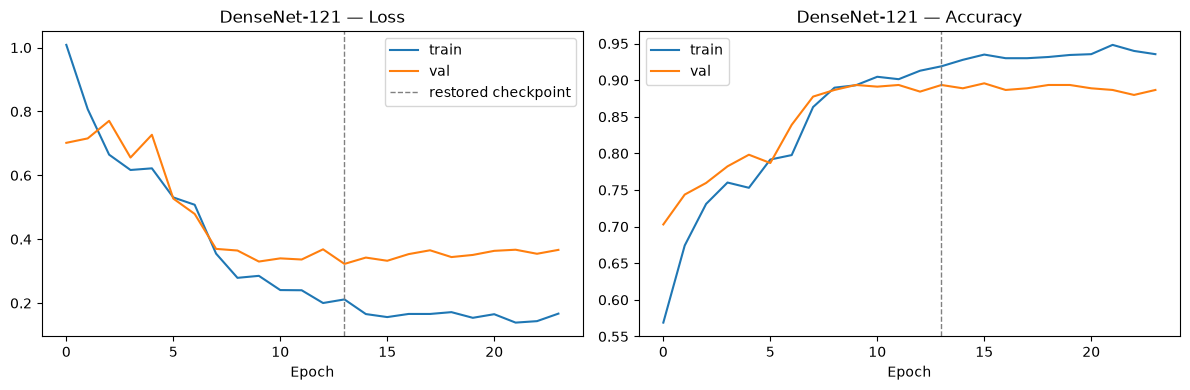

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.778


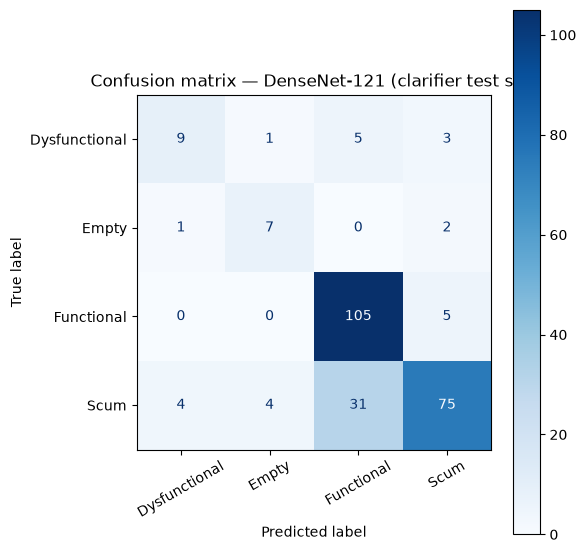

               precision    recall  f1-score   support

Dysfunctional      0.643     0.500     0.562        18
        Empty      0.583     0.700     0.636        10
   Functional      0.745     0.955     0.837       110
         Scum      0.882     0.658     0.754       114

     accuracy                          0.778       252
    macro avg      0.713     0.703     0.697       252
 weighted avg      0.793     0.778     0.772       252



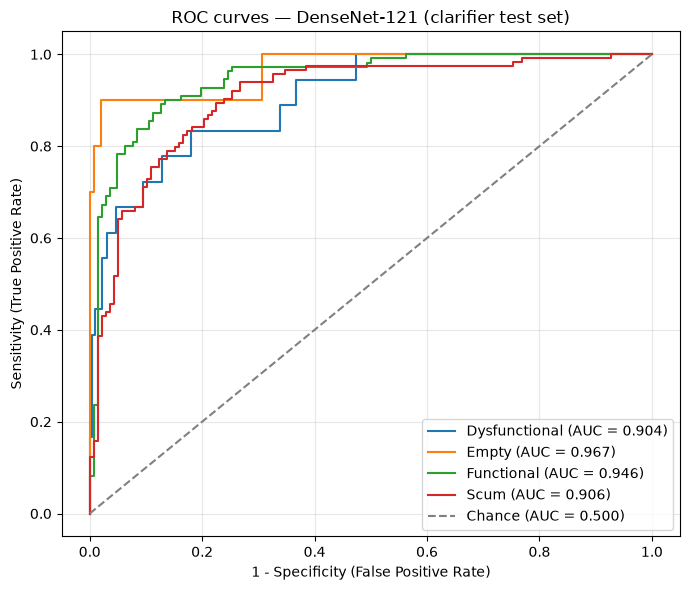

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.904
  Empty          : 0.967
  Functional     : 0.946
  Scum           : 0.906

Mean AUC (over 4/4 classes with test examples): 0.931


(np.float64(0.7777777777777778),
 {'Dysfunctional': 0.9040835707502375,
  'Empty': 0.9665289256198347,
  'Functional': 0.9458386683738795,
  'Scum': 0.9057335367404018})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/results_clarifier_densenet121_Fisantekraal.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
